In [1]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from db.database import Database
from util.dataframe_utils import get_dataframes
from sklearn.metrics.pairwise import cosine_similarity
import os
import pandas as pd

# Set seeds for reproducibility
import random
import torch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Force deterministic behavior
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
db = Database()
bp_df, topics_df, posts_df = get_dataframes(db)
# Sort by id to ensure consistent row order
bp_df = bp_df.sort_values("id").reset_index(drop=True)
bp_df.head()

,blueprint_hash,id,name,extracted_keywords,blueprint_code,blueprint_url,post_id,description,keywords_yake,topic_id,tags,created_at
0,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}",blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,"[""blueprint""]",2020-12-13 22:32:38.158
2,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[""switch"", ""blueprint"", ""deconz""]",2020-12-15 12:18:15.898
3,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [3]:
import json, re
def process_bp_keywords(kwd_dict: dict[str, int] | str) -> list[str] | None:
    if isinstance(kwd_dict, str):
        kwd_dict = json.loads(kwd_dict)
    
    kwd_list = list(kwd_dict.keys())
    if kwd_list.__len__() < 1:
        return None
    
    kwds = []
    
    for kwd in kwd_list:
        in_out = re.search(r"(input__|output__)(input_|output_)?", kwd)
        kwd = kwd.removeprefix(in_out.group()) if in_out else kwd
        in_out = in_out.group(1) if in_out else None
        kwds.append(in_out + kwd if in_out else kwd)
    return kwds

In [4]:
from difflib import SequenceMatcher
from nltk.stem import WordNetLemmatizer
def _normalize_feature_token(token: str) -> str:
    token = token.lower().strip()
    token = re.sub(r"[^\wÆØÅæøå]+", " ", token)
    token = re.sub(r"\s+", "_", token).strip()
    lemmatizer = WordNetLemmatizer()
    token = lemmatizer.lemmatize(token)
    return token

def _similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

def normalize_yake_features(features: list[str], threshold: float = 0.88, min_len: int = 4) -> list[str]:
    """
    Canonicalize YAKE keywords using fuzzy matching and simple containment rules.
    Keeps original order but maps near-duplicates to a shared canonical token.
    """
    canonicals: list[str] = []
    canonical_map: dict[str, str] = {}
    for raw in features:
        norm = _normalize_feature_token(raw)
        if not norm:
            continue
        if norm in canonical_map:
            canonical = canonical_map[norm]
            canonicals.append(canonical)
            continue
        canonical = norm
        for existing in set(canonical_map.values()):
            if min(len(norm), len(existing)) >= min_len and (norm in existing or existing in norm):
                canonical = existing if len(existing) <= len(norm) else norm
                break
            if _similarity(norm, existing) >= threshold:
                canonical = existing
                break
        canonical_map[norm] = canonical
        canonicals.append(canonical)
    return canonicals

In [5]:
ignorable_tags = {"blueprint", "automation"}
bp_df["tags"] = bp_df["tags"].apply(lambda tags: [tag for tag in json.loads(tags) if tag not in ignorable_tags])
bp_df.head()

,blueprint_hash,id,name,extracted_keywords,blueprint_code,blueprint_url,post_id,description,keywords_yake,topic_id,tags,created_at
0,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}",blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158
2,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898
3,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [6]:
max_keywords = bp_df["extracted_keywords"].apply(lambda x: len(json.loads(x)) if isinstance(x, str) else 0).max() 
max_tags = bp_df["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()
max_yake = 4
max_features = max_keywords + max_tags + max_yake
max_keywords, max_tags, max_features

(15, 5, 24)

In [7]:
def extract_features(row, max_features=max_features):
    padding = "<PAD>"
    
    yake_features = json.loads(row["keywords_yake"])
    yake_features = normalize_yake_features(yake_features)
    combined_features = list(yake_features)
    ext_kw = process_bp_keywords(row["extracted_keywords"])
    if ext_kw:
        combined_features.extend(ext_kw)
    
    kw_n = max_keywords - len(ext_kw) if ext_kw else max_keywords
    combined_features += [padding] * kw_n
    
    tags = row["tags"]
    tag_n = max_tags - len(tags)
    combined_features.extend(tags)
    combined_features += [padding] * tag_n

    return combined_features

In [8]:
from sklearn.preprocessing import normalize
import pickle

# Apply the updated function
bp_df["features"] = bp_df.apply(lambda row: extract_features(row, max_features=max_features), axis=1)
bp_df["features"] = bp_df["features"].apply(lambda x: " ".join(x))

# Cache embeddings to file for reproducibility
cache_file = "output/embeddings_cache.pkl"
if os.path.exists(cache_file):
    print("Loading cached embeddings...")
    with open(cache_file, "rb") as f:
        cached_data = pickle.load(f)
        bp_df["embeddings"] = cached_data["embeddings"]
        X = cached_data["X"]
        X_normalized = cached_data["X_normalized"]
else:
    print("Computing embeddings...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    # Process in deterministic single-threaded mode
    embeddings_list = []
    for text in bp_df["features"]:
        embedding = model.encode(text, show_progress_bar=False, convert_to_numpy=True)
        embeddings_list.append(embedding)
    
    bp_df["embeddings"] = embeddings_list
    X = np.vstack(bp_df["embeddings"].values)
    X_normalized = normalize(X, norm='l2')
    
    # Cache for future runs
    with open(cache_file, "wb") as f:
        pickle.dump({
            "embeddings": embeddings_list,
            "X": X,
            "X_normalized": X_normalized
        }, f)
    print("Embeddings cached.")
bp_df.head()

Loading cached embeddings...


,blueprint_hash,id,name,extracted_keywords,blueprint_code,blueprint_url,post_id,description,keywords_yake,topic_id,tags,created_at,features,embeddings
0,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}",blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,android_notification nag_prompt nag_notificati...,"[0.0199805, -0.00983637, 0.044692423, -0.08591..."
1,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.0039998735, -0.04323262, 0.007992302, 0.02..."
2,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,button_short button_remote long_press button i...,"[-0.018526876, -0.046502326, -0.06525874, -0.0..."
3,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,set_heating heating_temperature time set input...,"[0.043863416, 0.026248885, -0.06912752, 0.0384..."
4,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,light_allowance light allowance allotted input...,"[0.031691268, 0.015093141, -0.06533659, -0.000..."


In [9]:
from collections import Counter

def analyze_cluster_features(bp_df, cluster_id=None, fine_cluster=None, top_n=10):
    """Analyze the most common features in a specific cluster"""
    if cluster_id is not None and fine_cluster is not None:
        raise ValueError("Provide either cluster_id or fine_cluster, not both.")
    if cluster_id is not None:
        cluster_data = bp_df[bp_df["top_cluster"] == cluster_id]
    elif fine_cluster is not None:
        cluster_data = bp_df[bp_df["fine_cluster"] == fine_cluster]
    else:
        raise ValueError("Either cluster_id or fine_cluster must be provided.")
    
    all_features = []
    for features in cluster_data["features"]:
        feature_list = [f for f in features.split() if f != "<PAD>"]
        all_features.extend(feature_list)
    
    feature_counts = Counter(all_features)
    
    return feature_counts.most_common(top_n)

### Analysis

Silhouette score for k=2: 0.0630
Silhouette score for k=3: 0.0509
Silhouette score for k=4: 0.0551
Silhouette score for k=5: 0.0613
Silhouette score for k=6: 0.0715
Silhouette score for k=7: 0.0706
Silhouette score for k=8: 0.0689
Silhouette score for k=9: 0.0744
Silhouette score for k=10: 0.0819
Silhouette score for k=11: 0.0772
Silhouette score for k=12: 0.0829
Silhouette score for k=13: 0.0822
Silhouette score for k=14: 0.0803
Silhouette score for k=15: 0.0660
Silhouette score for k=16: 0.0656
Silhouette score for k=17: 0.0670
Silhouette score for k=18: 0.0676
Silhouette score for k=19: 0.0679
Silhouette score for k=20: 0.0709
Silhouette score for k=21: 0.0752
Silhouette score for k=22: 0.0739
Silhouette score for k=23: 0.0731
Silhouette score for k=24: 0.0730
Silhouette score for k=25: 0.0732
Silhouette score for k=26: 0.0723
Silhouette score for k=27: 0.0733
Silhouette score for k=28: 0.0712
Silhouette score for k=29: 0.0689
Silhouette score for k=30: 0.0679
Silhouette score for k

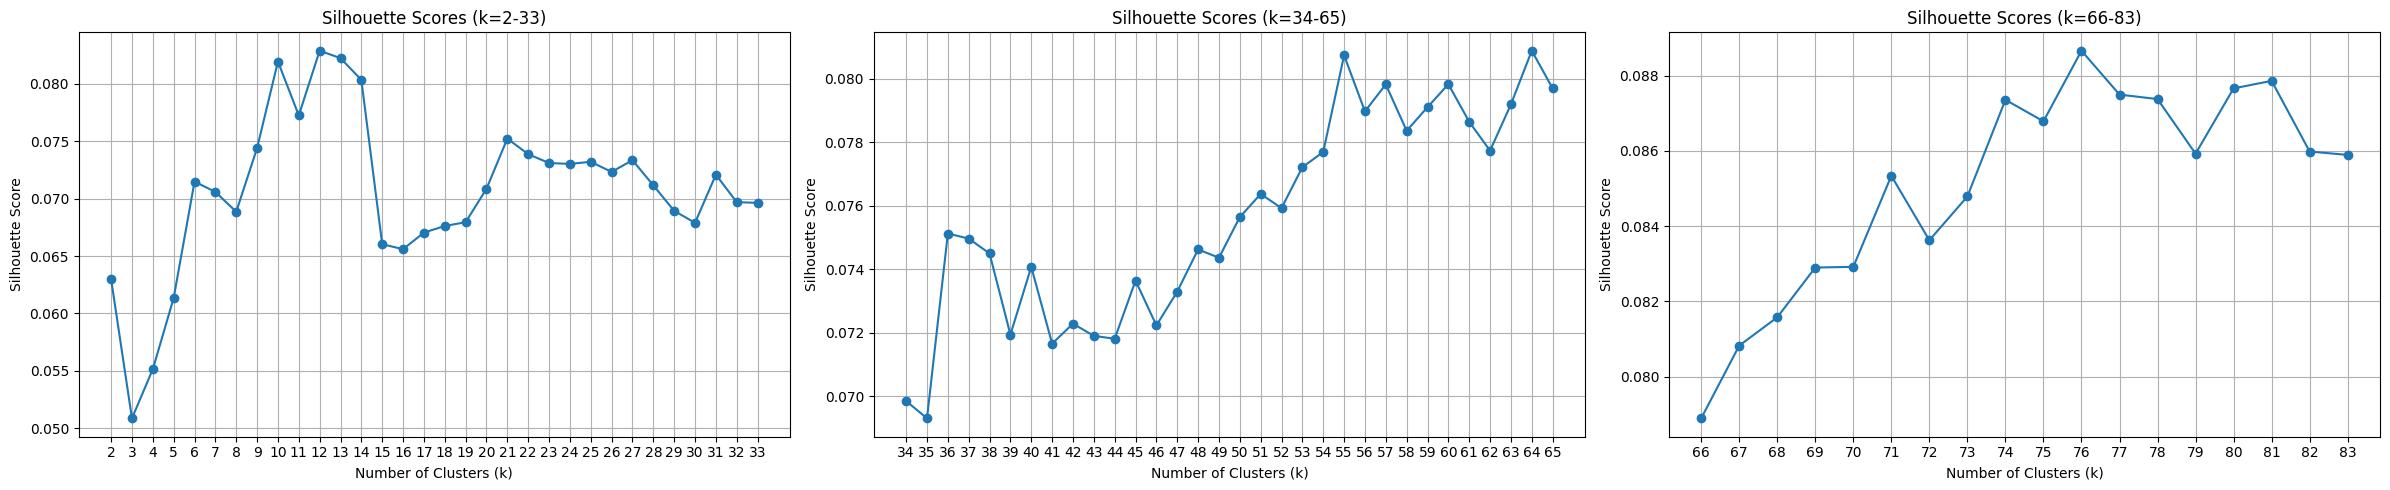

In [10]:
def plot_silhouette_scores(X, k_range):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
        print(f"Silhouette score for k={k}: {score:.4f}")
        
    max_scores = 32
    num_plots = (len(k_range) + max_scores - 1) // max_scores

    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 5))
    if num_plots == 1:
        axes = [axes]

    for plot_idx in range(num_plots):
        start_idx = plot_idx * max_scores
        end_idx = min(start_idx + max_scores, len(k_range))
        
        k_subset = list(k_range)[start_idx:end_idx]
        score_subset = scores[start_idx:end_idx]

        axes[plot_idx].plot(k_subset, score_subset, marker='o')
        axes[plot_idx].set_title(f"Silhouette Scores (k={k_subset[0]}-{k_subset[-1]})")
        axes[plot_idx].set_xlabel("Number of Clusters (k)")
        axes[plot_idx].set_ylabel("Silhouette Score")
        axes[plot_idx].set_xticks(k_subset)
        axes[plot_idx].grid()
    plt.tight_layout()
    plt.show()
plot_silhouette_scores(X_normalized, range(2, 84))

Silhouette score for k=2: 0.0630
Silhouette score for k=3: 0.0509
Silhouette score for k=4: 0.0551
Silhouette score for k=5: 0.0613
Silhouette score for k=6: 0.0715
Silhouette score for k=7: 0.0706
Silhouette score for k=8: 0.0689
Silhouette score for k=9: 0.0744
Silhouette score for k=10: 0.0819
Silhouette score for k=11: 0.0772
Silhouette score for k=12: 0.0829
Silhouette score for k=13: 0.0822
Silhouette score for k=14: 0.0803
Silhouette score for k=15: 0.0660
Silhouette score for k=16: 0.0656
Silhouette score for k=17: 0.0670
Silhouette score for k=18: 0.0676
Silhouette score for k=19: 0.0679
Silhouette score for k=20: 0.0709
Silhouette score for k=21: 0.0752
Silhouette score for k=22: 0.0739
Silhouette score for k=23: 0.0731
Silhouette score for k=24: 0.0730
Silhouette score for k=25: 0.0732
Silhouette score for k=26: 0.0723
Silhouette score for k=27: 0.0733
Silhouette score for k=28: 0.0712
Silhouette score for k=29: 0.0689
Silhouette score for k=30: 0.0679
Silhouette score for k

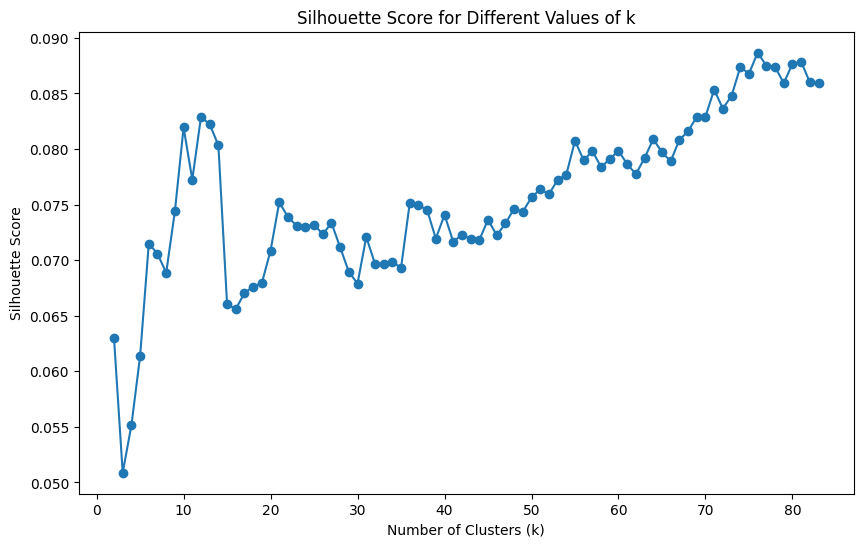

In [11]:
# silhoutte score in one plot
k_range = range(2, 84)
scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_normalized)
    score = silhouette_score(X_normalized, labels)
    scores.append(score)
    print(f"Silhouette score for k={k}: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")
plt.show()


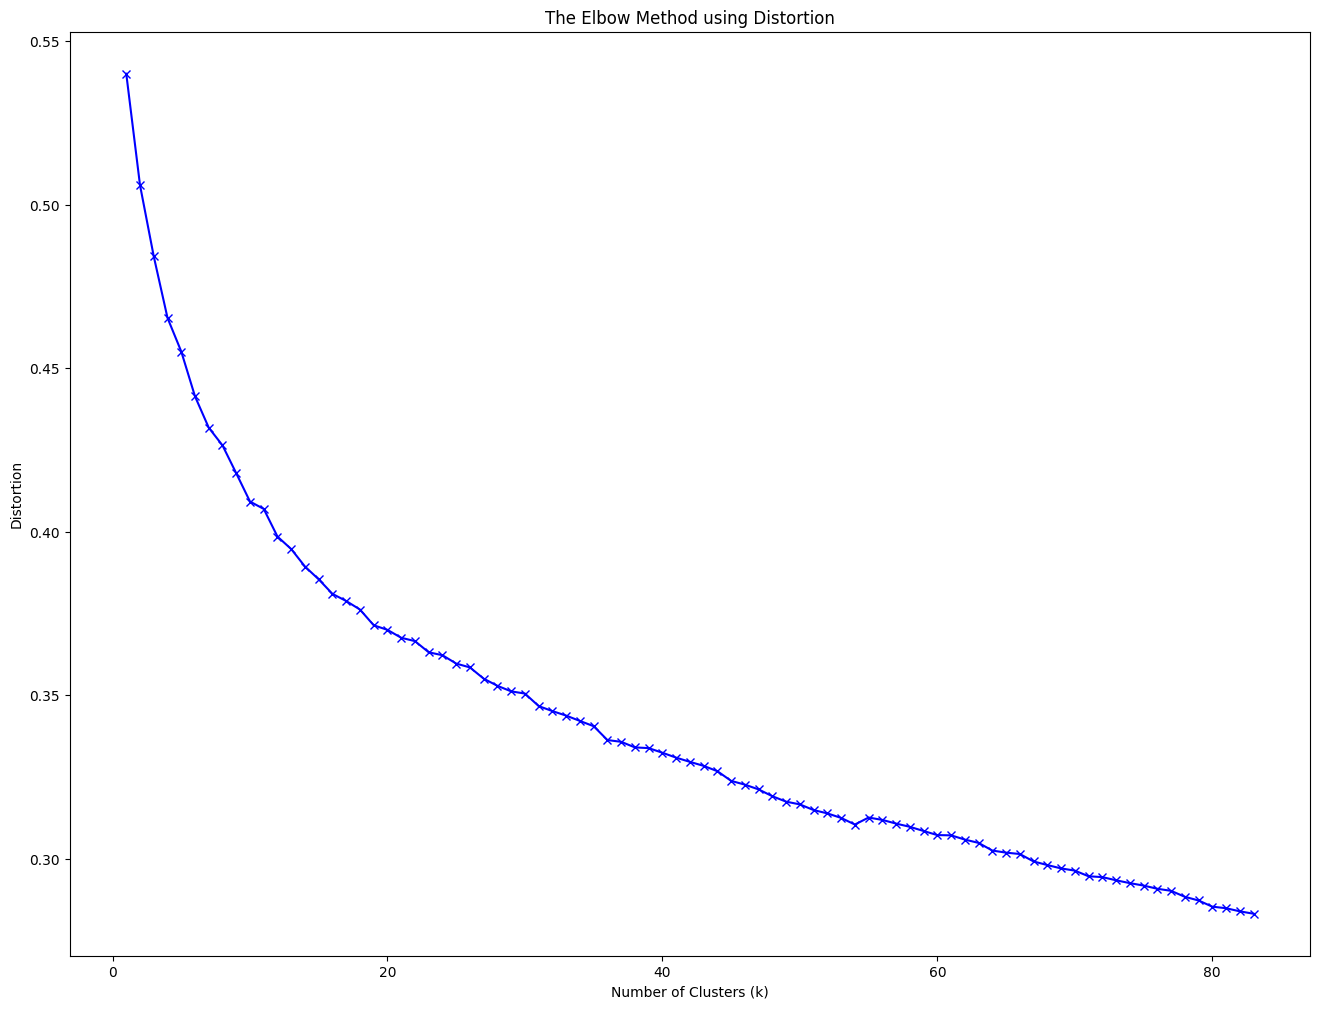

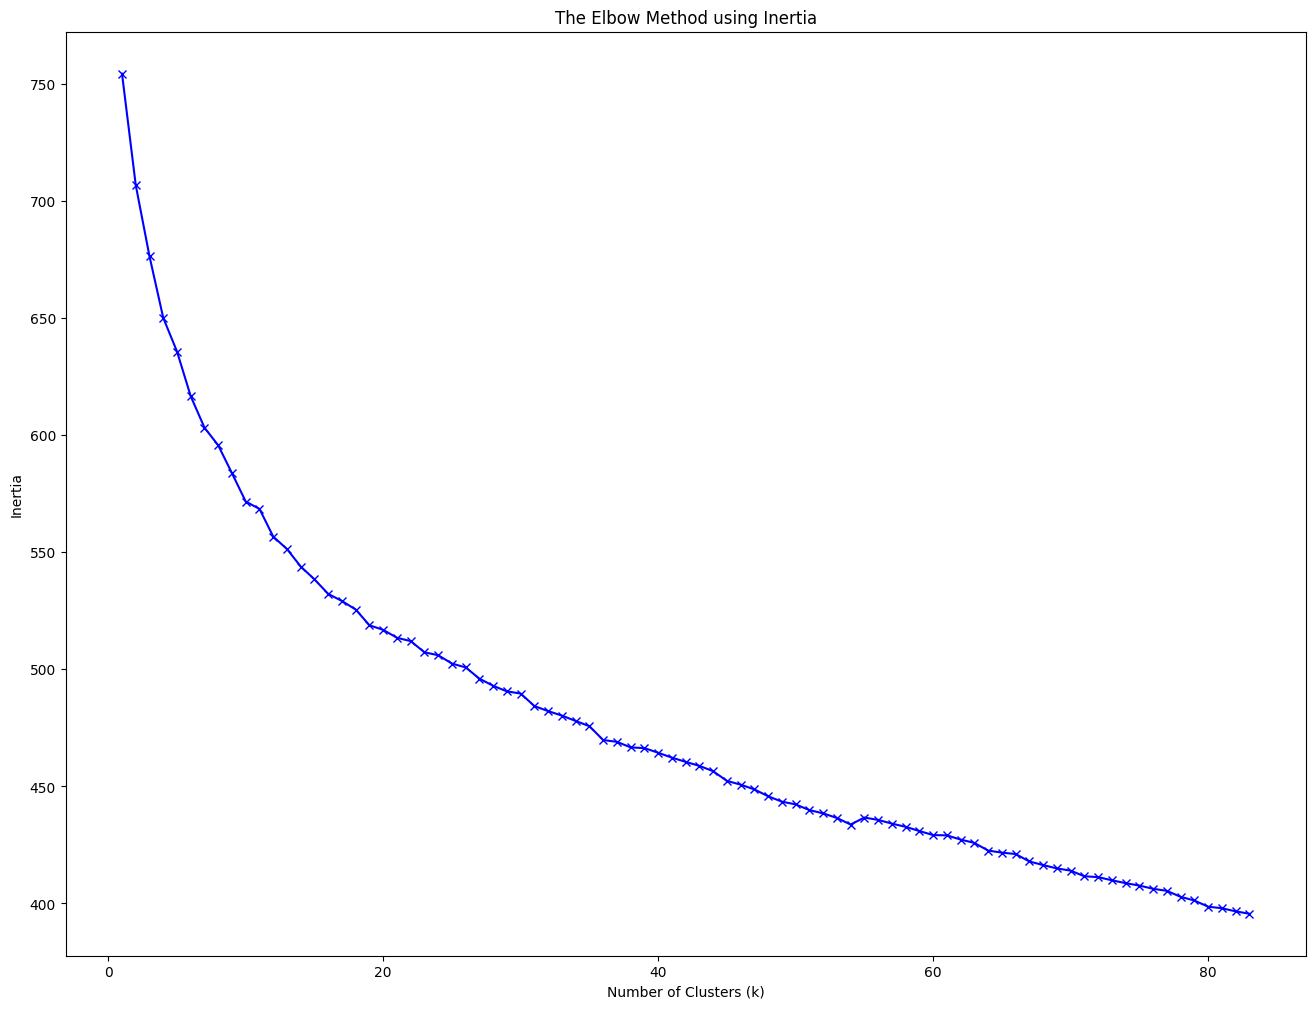

In [12]:
from scipy.spatial.distance import cdist
def plot_elbow(X, k_range):
    distortions = []
    inertias = []
    mapping1 = {}
    mapping2 = {}
    K = range(1, k_range.stop)
    for k in K:
        kmeanModel = KMeans(n_clusters=k, random_state=42)
        kmeanModel.fit(X)
        distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
        inertias.append(kmeanModel.inertia_)
        mapping1[k] = distortions[-1]
        mapping2[k] = inertias[-1]

    plt.figure(figsize=(16, 12))
    plt.plot(K, distortions, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title('The Elbow Method using Distortion')
    plt.show()
    plt.close()
    
    plt.figure(figsize=(16, 12))
    plt.plot(K, inertias, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('The Elbow Method using Inertia')
    plt.show()
    plt.close()
plot_elbow(X_normalized, range(2, 84))

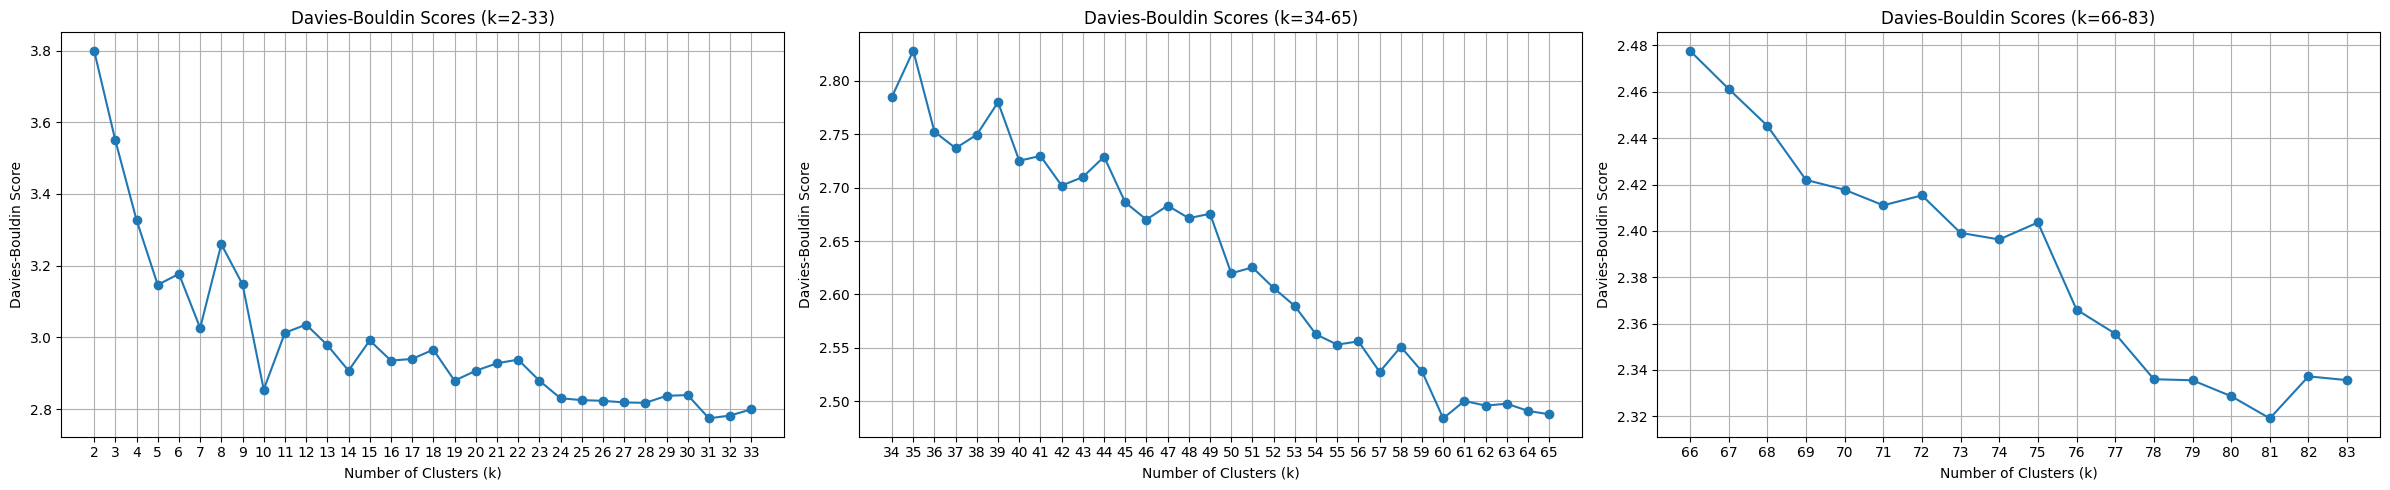

In [13]:
from sklearn.metrics import davies_bouldin_score
def davies_bouldin_scores(X, k_range):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = davies_bouldin_score(X, labels)
        scores.append(score)
    
        
    max_scores = 32
    num_plots = (len(k_range) + max_scores - 1) // max_scores

    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 5))
    if num_plots == 1:
        axes = [axes]

    for plot_idx in range(num_plots):
        start_idx = plot_idx * max_scores
        end_idx = min(start_idx + max_scores, len(k_range))
        
        k_subset = list(k_range)[start_idx:end_idx]
        score_subset = scores[start_idx:end_idx]

        axes[plot_idx].plot(k_subset, score_subset, marker='o')
        axes[plot_idx].set_title(f"Davies-Bouldin Scores (k={k_subset[0]}-{k_subset[-1]})")
        axes[plot_idx].set_xlabel("Number of Clusters (k)")
        axes[plot_idx].set_ylabel("Davies-Bouldin Score")
        axes[plot_idx].set_xticks(k_subset)
        axes[plot_idx].grid()
    plt.tight_layout()
    plt.show()
davies_bouldin_scores(X_normalized, range(2, 84))

Davies-Bouldin score for k=2: 3.7994
Davies-Bouldin score for k=3: 3.5495
Davies-Bouldin score for k=4: 3.3275
Davies-Bouldin score for k=5: 3.1467
Davies-Bouldin score for k=6: 3.1773
Davies-Bouldin score for k=7: 3.0266
Davies-Bouldin score for k=8: 3.2599
Davies-Bouldin score for k=9: 3.1480
Davies-Bouldin score for k=10: 2.8549
Davies-Bouldin score for k=11: 3.0131
Davies-Bouldin score for k=12: 3.0360
Davies-Bouldin score for k=13: 2.9788
Davies-Bouldin score for k=14: 2.9075
Davies-Bouldin score for k=15: 2.9918
Davies-Bouldin score for k=16: 2.9357
Davies-Bouldin score for k=17: 2.9401
Davies-Bouldin score for k=18: 2.9660
Davies-Bouldin score for k=19: 2.8796
Davies-Bouldin score for k=20: 2.9071
Davies-Bouldin score for k=21: 2.9280
Davies-Bouldin score for k=22: 2.9382
Davies-Bouldin score for k=23: 2.8796
Davies-Bouldin score for k=24: 2.8306
Davies-Bouldin score for k=25: 2.8253
Davies-Bouldin score for k=26: 2.8234
Davies-Bouldin score for k=27: 2.8189
Davies-Bouldin score

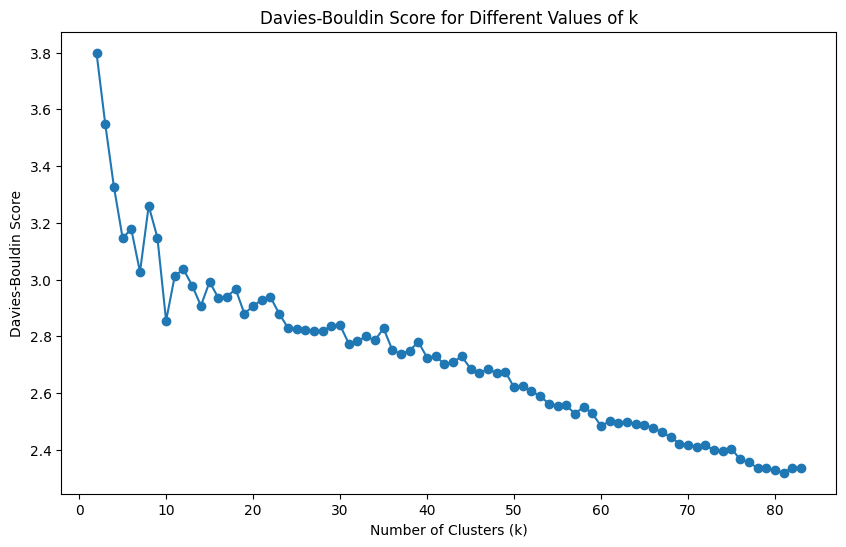

In [14]:
#davies bouldin score in one plot
k_range = range(2, 84)
scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_normalized)
    score = davies_bouldin_score(X_normalized, labels)
    scores.append(score)
    print(f"Davies-Bouldin score for k={k}: {score:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score for Different Values of k")
plt.show()


### Two-stage KMeans (top-down)

In [10]:
k_top = 15
kmeans_top = KMeans(n_clusters=k_top, random_state=42)
bp_df["top_cluster"] = kmeans_top.fit_predict(X_normalized)

In [11]:
bp_df["sub_cluster"] = -1

for c in range(k_top):
    mask = bp_df["top_cluster"] == c
    X_sub = X_normalized[mask]
    
    if len(X_sub) < 10:
        continue
    
    k_sub = min(5, len(X_sub) // 5)
    km = KMeans(n_clusters=k_sub, random_state=42)

    bp_df.loc[mask, "sub_cluster"] = km.fit_predict(X_sub)

In [ ]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(kmeans_top.n_clusters):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            sub_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["sub_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, sub_clusters))} \n\n")
            for sub_cluster in sub_clusters:
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["sub_cluster"] == sub_cluster)]
                f.write(f"### Sub-cluster {sub_cluster}\n\n")
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
c_name = "hierarchical_clusters_norm_15_5"
write_to_md(f"output/{c_name}.md")

### Agglomerative clustering on centroids (bottom-up)

In [10]:
kmeans = KMeans(n_clusters=55, random_state=42, n_init="auto")
bp_df["fine_cluster"] = kmeans.fit_predict(X_normalized)

centroids = kmeans.cluster_centers_

# Create a stable sort key using multiple dimensions to avoid ties
# Sort by lexicographic ordering of all dimensions
sort_keys = [tuple(c) for c in centroids]
sorted_indices = sorted(range(len(sort_keys)), key=lambda i: sort_keys[i])
centroids_sorted = centroids[sorted_indices]
cluster_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted_indices)}
bp_df["fine_cluster"] = bp_df["fine_cluster"].map(cluster_mapping)

In [11]:
from collections import Counter

def analyze_cluster_features(bp_df, cluster_id, top_n=10):
    """Analyze the most common features in a specific cluster"""
    cluster_data = bp_df[bp_df["fine_cluster"] == cluster_id]
    
    all_features = []
    for features in cluster_data["features"]:
        feature_list = [f for f in features.split() if f != "<PAD>"]
        all_features.extend(feature_list)
    
    feature_counts = Counter(all_features)
    
    """ print(f"\nTop {top_n} features in Cluster {cluster_id}:")
    for feature, count in feature_counts.most_common(top_n):
        print(f"  {feature}: {count}") """
    
    return feature_counts.most_common(top_n)

for cluster_id in range(kmeans.n_clusters):
    analyze_cluster_features(bp_df, cluster_id, top_n=5)

In [12]:
from collections import Counter, defaultdict

cluster_features = defaultdict(list)
for idx, row in bp_df.iterrows():
    cluster_id = row["fine_cluster"]
    feature_list = [f for f in row["features"].split() if f != "<PAD>"]
    cluster_features[cluster_id].extend(feature_list)

# Calculate feature frequencies per cluster
cluster_feature_counts = {}
for cluster_id, features in cluster_features.items():
    cluster_feature_counts[cluster_id] = Counter(features)

# Find features that are distinctive (appear heavily in some clusters but not others)
all_features = set()
for counts in cluster_feature_counts.values():
    all_features.update(counts.keys())

# Calculate variance in feature distribution across clusters
feature_variance = {}
for feature in all_features:
    counts = [cluster_feature_counts[c].get(feature, 0) for c in range(kmeans.n_clusters)]
    feature_variance[feature] = np.var(counts)

# Sort by variance (higher variance = more distinctive)
sorted_features = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 most distinctive features across clusters:")
for feature, variance in sorted_features[:20]:
    print(f"  {feature}: variance={variance:.2f}")
    cluster_presence = [(c, cluster_feature_counts[c].get(feature, 0)) 
                       for c in range(kmeans.n_clusters) 
                       if cluster_feature_counts[c].get(feature, 0) > 0]
    cluster_presence.sort(key=lambda x: x[1], reverse=True)
    print(f"    Most common in clusters: {cluster_presence[:3]}")


Top 20 most distinctive features across clusters:
  light: variance=247.13
    Most common in clusters: [(48, 90), (33, 74), (18, 23)]
  switch: variance=185.29
    Most common in clusters: [(11, 81), (30, 37), (8, 36)]
  input__binary_sensor: variance=122.32
    Most common in clusters: [(48, 77), (29, 22), (43, 17)]
  button: variance=80.74
    Most common in clusters: [(19, 39), (8, 30), (18, 30)]
  zigbee2mqtt: variance=57.91
    Most common in clusters: [(27, 36), (11, 34), (19, 25)]
  input__sensor: variance=56.92
    Most common in clusters: [(29, 34), (15, 22), (48, 22)]
  temperature: variance=56.90
    Most common in clusters: [(37, 48), (34, 30), (51, 8)]
  output__light: variance=52.23
    Most common in clusters: [(48, 44), (18, 20), (27, 18)]
  zigbee: variance=48.56
    Most common in clusters: [(3, 33), (11, 24), (19, 23)]
  press: variance=46.97
    Most common in clusters: [(19, 43), (10, 16), (11, 16)]
  motion: variance=43.12
    Most common in clusters: [(48, 49),

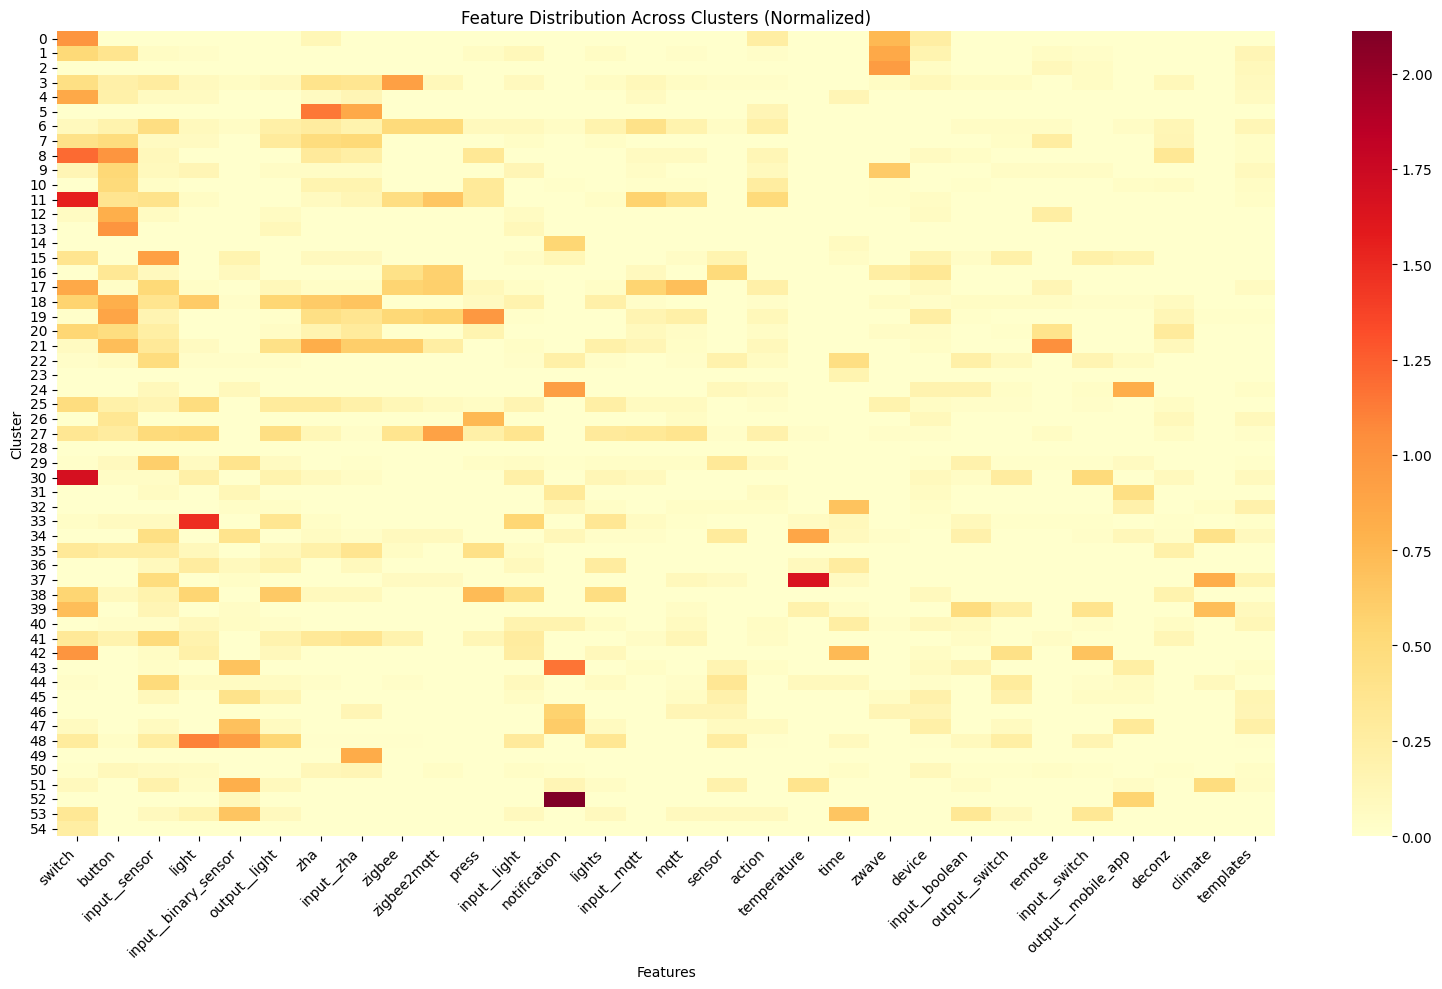

In [13]:
import seaborn as sns

# Get top features overall
all_feature_counts = Counter()
for features in bp_df["features"]:
    feature_list = [f for f in features.split() if f != "<PAD>"]
    all_feature_counts.update(feature_list)

top_features = [f for f, _ in all_feature_counts.most_common(30)]

# Create matrix: clusters x features
matrix = np.zeros((kmeans.n_clusters, len(top_features)))
for cluster_id in range(kmeans.n_clusters):
    cluster_counts = cluster_feature_counts[cluster_id]
    for i, feature in enumerate(top_features):
        matrix[cluster_id, i] = cluster_counts.get(feature, 0)

# Normalize by cluster size
cluster_sizes = bp_df["fine_cluster"].value_counts().sort_index()
matrix = matrix / cluster_sizes.values[:, np.newaxis]

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(matrix, xticklabels=top_features, yticklabels=range(kmeans.n_clusters), 
            cmap='YlOrRd', annot=False)
plt.title("Feature Distribution Across Clusters (Normalized)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.4,
    metric="cosine",
    linkage="average",
    compute_distances=True
)

model = agg.fit(centroids_sorted)
top_labels = model.labels_

In [15]:
bp_df["top_cluster"] = bp_df["fine_cluster"].map(dict(enumerate(top_labels)))
bp_df.head()

,blueprint_hash,id,name,extracted_keywords,blueprint_code,blueprint_url,post_id,description,keywords_yake,topic_id,tags,created_at,features,embeddings,fine_cluster,top_cluster
0,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,1,Nag prompt blueprint,"{""input__input_boolean"": 2}",blueprint:\n name: Nag prompt blueprint\n de...,https://community.home-assistant.io//t/nag-pro...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,android_notification nag_prompt nag_notificati...,"[0.0199805, -0.00983637, 0.044692423, -0.08591...",24,0
1,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,2,Inovelli,{},blueprint:\n name: Inovelli \n description: ...,https://community.home-assistant.io//t/inovell...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.0039998735, -0.04323262, 0.007992302, 0.02...",25,0
2,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,3,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",blueprint:\n name: deCONZ - IKEA five button ...,https://community.home-assistant.io//t/deconz-...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,button_short button_remote long_press button i...,"[-0.018526876, -0.046502326, -0.06525874, -0.0...",20,0
3,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,4,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",blueprint:\n name: Heat for certain time\n d...,https://community.home-assistant.io//t/set-hea...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,set_heating heating_temperature time set input...,"[0.043863416, 0.026248885, -0.06912752, 0.0384...",39,0
4,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,5,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",blueprint:\n name: Light Allowance\n descrip...,https://community.home-assistant.io//t/light-a...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,light_allowance light allowance allotted input...,"[0.031691268, 0.015093141, -0.06533659, -0.000...",33,0


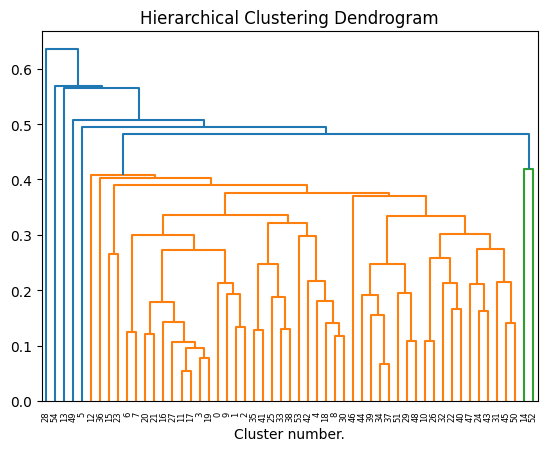

In [16]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
    
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level")
plt.xlabel("Cluster number.")
plt.show()

In [15]:
bp_df["top_cluster"].unique().shape

(10,)

In [16]:
for cluster_id in bp_df["top_cluster"].unique():
    features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=10)
    print(f"Cluster {cluster_id}:")
    for feature, count in features:
        print(f"  {feature}: {count}")

Cluster 0:
  switch: 423
  input__sensor: 317
  button: 290
  light: 280
  input__binary_sensor: 193
  output__light: 181
  zha: 175
  input__zha: 167
  zigbee: 160
  zigbee2mqtt: 150
Cluster 3:
  notification: 7
  reminder: 5
  telegram: 4
  conversation_agent: 4
  agent: 4
  conversation: 4
  input__calendar: 4
  calendar: 4
  weather: 2
  bot: 2
Cluster 5:
  zha: 8
  cube: 8
  aqara: 7
  input__zha: 6
  rotate: 5
  face: 4
  side: 4
  output__number: 2
  work: 1
  event: 1
Cluster 8:
  pico: 21
  button: 13
  input__lutron_caseta: 13
  lutron: 12
  remote: 4
  work: 4
  lutron_caseta: 3
  lutron_pico: 3
  paddle_remote: 2
  cover: 2
Cluster 1:
  input__zha: 5
  cluster: 3
  double_dots: 2
  dot: 2
  cluster_command: 2
  unknown_cluster: 2
  output__media_player: 2
  stage_succeeded: 2
  command: 2
  false: 2
Cluster 2:
  entity: 5
  single_run: 3
  run_mode: 3
  state: 2
  switch: 1
  actions_oema: 1
  offline_entity: 1
Cluster 4:
  sun: 5
  elevation: 4
  sunset: 3
  light: 3
  lig

In [17]:
top_to_fine = {}
for label, idx in enumerate(top_labels):
    top_to_fine[label] = idx
top_to_fine

{0: 0,
 1: 0,
 2: 0,
 3: 0,
 4: 0,
 5: 5,
 6: 0,
 7: 0,
 8: 0,
 9: 0,
 10: 0,
 11: 0,
 12: 8,
 13: 7,
 14: 3,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 0,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 9,
 29: 0,
 30: 0,
 31: 0,
 32: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 4,
 37: 0,
 38: 0,
 39: 0,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 0,
 49: 1,
 50: 0,
 51: 0,
 52: 6,
 53: 0,
 54: 2}

In [18]:
similarity_matrix = cosine_similarity(centroids_sorted)
threshold = 0.50
pairs = []
for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[1]):
        sim = similarity_matrix[i, j]
        if sim >= threshold:
            pairs.append((i, j, sim))
            
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
for i, j, sim in pairs:
    if top_to_fine.get(i) != top_to_fine.get(j):
        print(f"Fine clusters {i} and {j} have similarity {sim:.2f}")

Fine clusters 14 and 40 have similarity 0.77
Fine clusters 43 and 52 have similarity 0.75
Fine clusters 10 and 12 have similarity 0.75
Fine clusters 12 and 26 have similarity 0.73
Fine clusters 33 and 36 have similarity 0.73
Fine clusters 24 and 52 have similarity 0.73
Fine clusters 12 and 18 have similarity 0.73
Fine clusters 12 and 20 have similarity 0.72
Fine clusters 5 and 10 have similarity 0.70
Fine clusters 8 and 12 have similarity 0.70
Fine clusters 29 and 36 have similarity 0.69
Fine clusters 14 and 32 have similarity 0.69
Fine clusters 14 and 24 have similarity 0.69
Fine clusters 14 and 31 have similarity 0.69
Fine clusters 10 and 14 have similarity 0.69
Fine clusters 10 and 36 have similarity 0.69
Fine clusters 36 and 40 have similarity 0.68
Fine clusters 12 and 29 have similarity 0.68
Fine clusters 53 and 54 have similarity 0.67
Fine clusters 14 and 43 have similarity 0.67
Fine clusters 32 and 36 have similarity 0.66
Fine clusters 36 and 48 have similarity 0.66
Fine cluster

In [19]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(agg.n_clusters_):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            fine_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["fine_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, fine_clusters))} \n\n")
            for fine_cluster in fine_clusters:
                f.write(f"<details>\n")
                f.write(f"<summary> Sub-cluster {fine_cluster} </summary>\n\n")
                features = analyze_cluster_features(bp_df, fine_cluster=fine_cluster, top_n=5)
                f.write(f"Top 5 features: \n")
                for feature, count in features:
                    f.write(f"- {feature}: {count} \n")
                f.write("\n")
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["fine_cluster"] == fine_cluster)]
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
                f.write(f"</details>\n\n")
            f.write(f"</details>\n\n")
c_name = "agg_clusters_new_filtering"
write_to_md(f"output/{c_name}.md")

In [20]:
bp_df[bp_df["topic_id"] == "941758"]

,blueprint_hash,id,name,extracted_keywords,blueprint_code,blueprint_url,post_id,description,keywords_yake,topic_id,tags,created_at,features,embeddings,fine_cluster,top_cluster
1377,e72c523c3cfa5b58208bd45b0f7f9dd802446ef0352992...,2202,Oil Diffuser Ai,"{""input__binary_sensor"": 2, ""input__occupancy""...",blueprint:\n name: Oil Diffuser Ai\n descrip...,https://github.com/zodyking/oil-diffuser-bluep...,3611816,![OilDiffuser](https://raw.githubusercontent.c...,"[""outlet"", ""cycle"", ""presence"", ""tts""]",941758,[],2025-10-19 01:35:37.951,outlet cycle presence tt input__binary_sensor ...,"[0.047205087, -0.022137826, -0.0936268, -0.107...",45,0


In [21]:
bp_df = bp_df.drop(columns=["embeddings"]) if "embeddings" in bp_df.columns else bp_df
for col in bp_df.columns:
    bp_df[col] = bp_df[col].apply(lambda x: json.dumps(x) if isinstance(x, (list, dict)) else x)
bp_df.to_sql("blueprints_categorized", db.engine.connect(), if_exists="replace", index=False)
db.engine.dispose()

In [22]:
bp_df.to_pickle("output/bp_clusters_hierarchical.pkl")

In [23]:
features = bp_df["features"].tolist()

In [24]:
features

['android_notification nag_prompt nag_notifications notification_target input__boolean <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>',
 'fan inovelli create dimmer <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>',
 'button_short button_remote long_press button input__deconz <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> switch deconz <PAD> <PAD> <PAD>',
 'set_heating heating_temperature time set input__datetime input__climate <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>',
 'light_allowance light allowance allotted input__light output__light <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>',
 'run_actions run action action input__sensor <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PA

In [25]:
top_cluster_with_sub_cluster_list = {}
for top_cluster in bp_df["top_cluster"].unique():
    sub_clusters = bp_df[bp_df["top_cluster"] == top_cluster]["fine_cluster"].unique().tolist()
    top_cluster_with_sub_cluster_list[top_cluster] = sub_clusters
top_cluster_with_sub_cluster_list

{0: [24,
  25,
  20,
  39,
  33,
  29,
  34,
  40,
  50,
  45,
  2,
  7,
  48,
  17,
  27,
  0,
  6,
  26,
  15,
  31,
  43,
  51,
  37,
  8,
  11,
  1,
  9,
  35,
  18,
  19,
  53,
  32,
  10,
  41,
  30,
  44,
  21,
  3,
  22,
  38,
  46,
  4,
  42,
  47,
  16,
  23],
 3: [14],
 5: [5],
 8: [12],
 1: [49],
 2: [54],
 4: [36],
 6: [52],
 7: [13],
 9: [28]}